Second iteration of heat flux estimate
Based on instationary 1D heat flow equations
Trying to solve for q_dot by looking at the temp changes


# Heat Flux Reconstruction from Probe Temperature

This notebook models a 1D radial transient heat conduction system consisting of:
- Semi-infinite copper (CuCrZr)
- Thin thermal paste layer (~0.05 mm)
- Temperature probe with known mass and heat capacity

The goal is to reconstruct the **heat flux at the paste-probe interface** from measured probe temperatures.

## 1. Import libraries

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

## 2. Input data
Replace the example data below with your measured probe temperatures and time array.

## Load Temperature Data from CSV (InfluxDB format)
Reads the CSV file exported from your sensor database, skipping metadata lines,
and converts timestamps to elapsed seconds for modeling.

In [111]:
# File path (adjust filename as needed)
filename = 'data/Firing8_ENG_WLL_T3.csv'

# Load CSV while skipping metadata lines starting with '#'
df = pd.read_csv(filename, comment='#')

# Convert _time column to pandas datetime
df['_time'] = pd.to_datetime(df['_time'])

# Sort by time just in case data is unordered
df = df.sort_values('_time').reset_index(drop=True)

# Convert timestamps to elapsed seconds relative to first sample
time_seconds = (df['_time'] - df['_time'].iloc[0]).dt.total_seconds().values

# Extract temperature measurements
temperature = df['_value'].values

print(f"Loaded {len(time_seconds)} samples from {df['_time'].iloc[0]} to {df['_time'].iloc[-1]}")

Loaded 1119 samples from 2026-04-02 18:58:00.119834880+00:00 to 2026-04-02 19:00:19.939264+00:00


## Assign Data for Heat Flux Model
Assign the loaded time and temperature arrays to variables used in the model.

In [112]:
# Time array [s]
t = time_seconds
# Probe Temps
T_probe_meas = temperature

## 3. Material properties and geometry

In [113]:
# Copper (CuCrZr ~ copper)
k_cu = 380       # W/mK
rho_cu = 8900    # kg/m3
cp_cu = 385      # J/kgK
alpha_cu = k_cu / (rho_cu * cp_cu)

# Thermal paste
k_paste = 2.6    # W/mK
t_paste = 5e-5   # 0.05 mm

# Probe properties (EDIT THESE!)
m_probe = 0.00000895  # kg
cp_probe = 500   # J/kgK
C_probe = m_probe * cp_probe

# Contact area of probe
r_probe = 3e-3   # 3 mm radius
A = np.pi * r_probe**2

# Thermal resistance of paste layer
R_paste = t_paste / (k_paste * A)

## 4. Preprocessing
- Compute time step
- Smooth measured probe temperature to reduce noise

In [114]:
dt = t[1] - t[0]

# Smooth measured probe temperature
# T_probe = savgol_filter(T_probe_meas, 51, 3)
T_probe = T_probe_meas

## 5. Initialize arrays for heat flux and copper surface temperature

In [115]:
N = len(t)
q = np.zeros(N)             # heat flux [W/m2]
T_surface = np.zeros(N)     # copper surface temperature

## 6. Forward-step inverse solver
- Uses semi-infinite copper convolution
- Updates heat flux iteratively to match probe temperature

In [116]:
for n in range(1, N):
    # --- Step 1: compute copper surface temp via semi-infinite convolution ---
    integral = 0.0
    for i in range(n):
        tau = t[n] - t[i]
        if tau > 0:
            integral += q[i] * dt / np.sqrt(np.pi * alpha_cu * tau)
    T_surface[n] = integral / k_cu
    
    # --- Step 2: compute heat flux from paste layer ---
    q[n] = (T_surface[n] - T_probe[n]) / R_paste

## 7. Smooth the heat flux (optional)

In [117]:
# q_smooth = savgol_filter(q, 51, 3)
q_smooth = q

## 8. Plot results

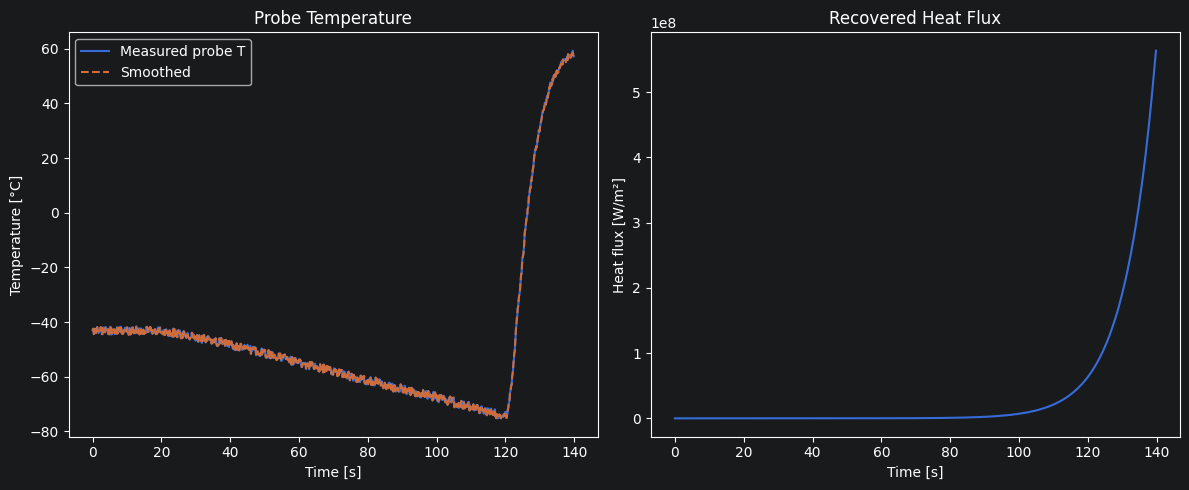

In [118]:
plt.figure(figsize=(12,5))

# Probe temperature
plt.subplot(1,2,1)
plt.plot(t, T_probe_meas, label="Measured probe T")
plt.plot(t, T_probe, label="Smoothed", linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.title("Probe Temperature")

# Recovered heat flux
plt.subplot(1,2,2)
plt.plot(t, q_smooth)
plt.xlabel("Time [s]")
plt.ylabel("Heat flux [W/m²]")
plt.title("Recovered Heat Flux")

plt.tight_layout()
plt.show()

## 9. Next Steps / Tips
- Replace the example `T_probe_meas` with your logged measurements.
- Adjust `m_probe`, `cp_probe`, `r_probe`, and `k_paste` for your setup.
- If computation becomes slow for long datasets, consider FFT-based convolution.
- Remember: the inverse problem is sensitive to noise; smoothing your probe data is crucial.